In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All imports successful")


All imports successful


In [8]:
import pandas as pd
df = pd.read_csv(r'd:\Projects\credit-risk-network\data\raw\cs-training.csv\cs-training.csv', index_col=0)
print("Shape:", df.shape)

Shape: (150000, 11)


In [9]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DEFAULT RATE ===")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3))

=== DATA TYPES ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== MISSING VALUES ===
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
N

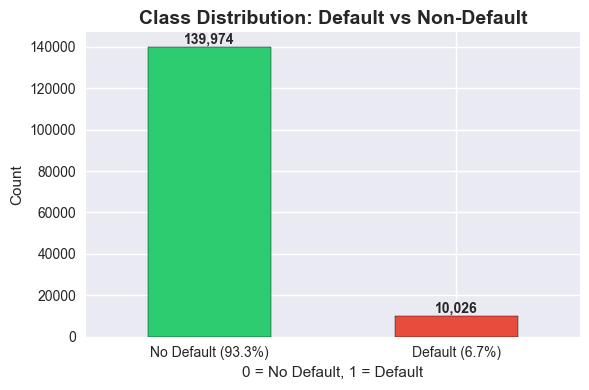

Plot saved.


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar', 
    color=colors, 
    ax=ax, 
    edgecolor='black'
)
ax.set_title('Class Distribution: Default vs Non-Default', fontsize=14, fontweight='bold')
ax.set_xlabel('0 = No Default, 1 = Default')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Default (93.3%)', 'Default (6.7%)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()), 
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

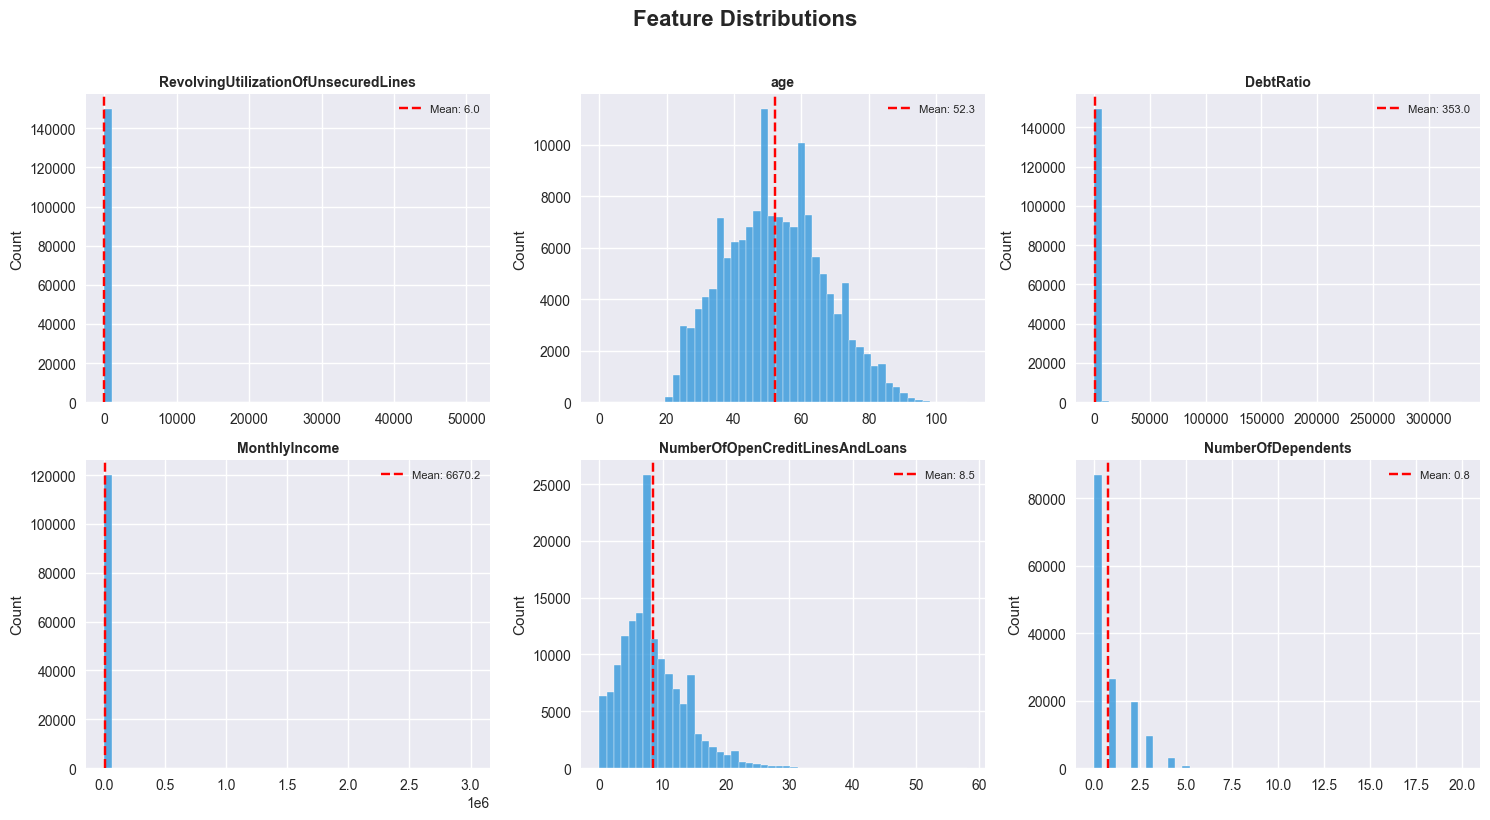

Plot saved.


In [11]:
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 
    'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

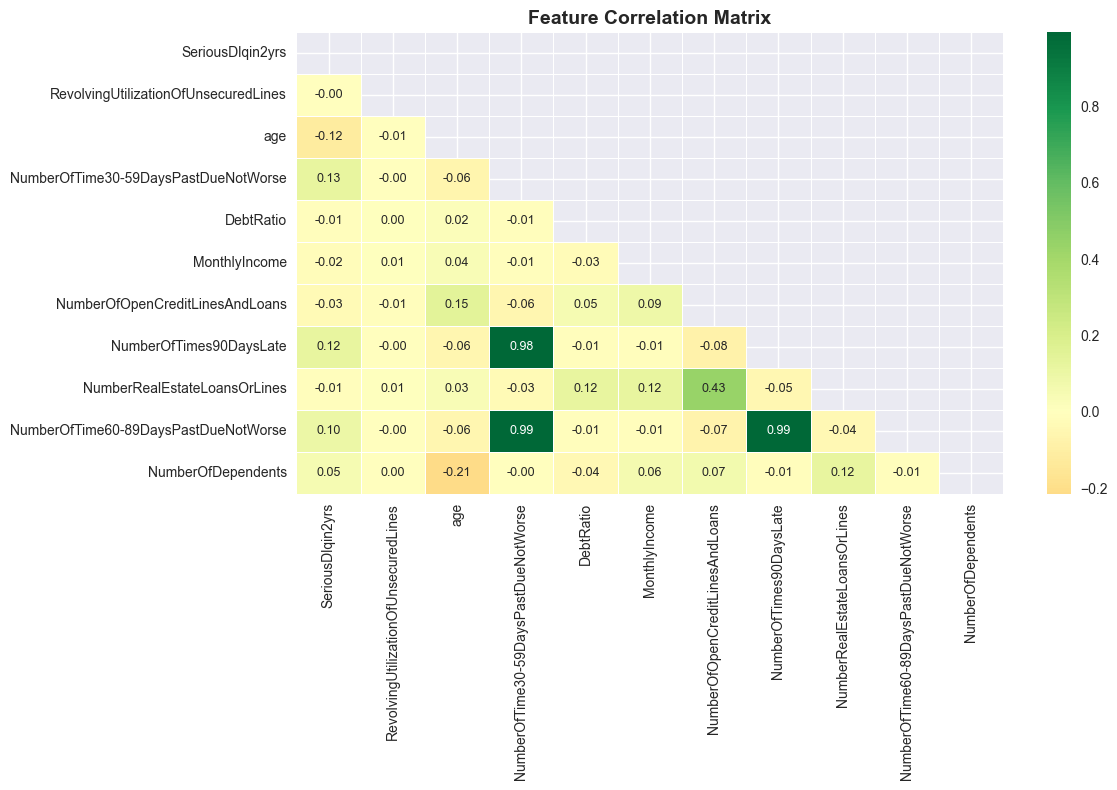

Plot saved.


In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = df.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9}
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

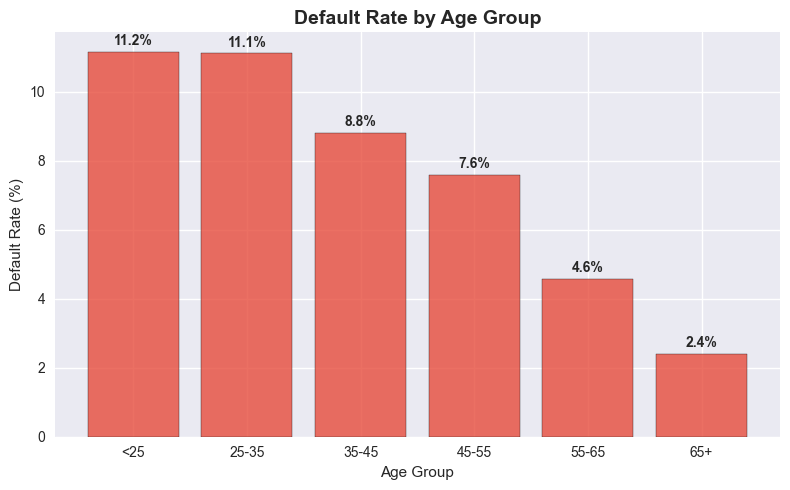

Plot saved.


In [13]:
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 25, 35, 45, 55, 65, 100], 
                          labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+'])

default_by_age = df.groupby('age_group', observed=True)['SeriousDlqin2yrs'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(default_by_age.index, default_by_age.values, 
              color='#e74c3c', edgecolor='black', alpha=0.8)

ax.set_title('Default Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Default Rate (%)')

for bar, val in zip(bars, default_by_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/04_default_rate_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop('age_group', axis=1, inplace=True)
print("Plot saved.")

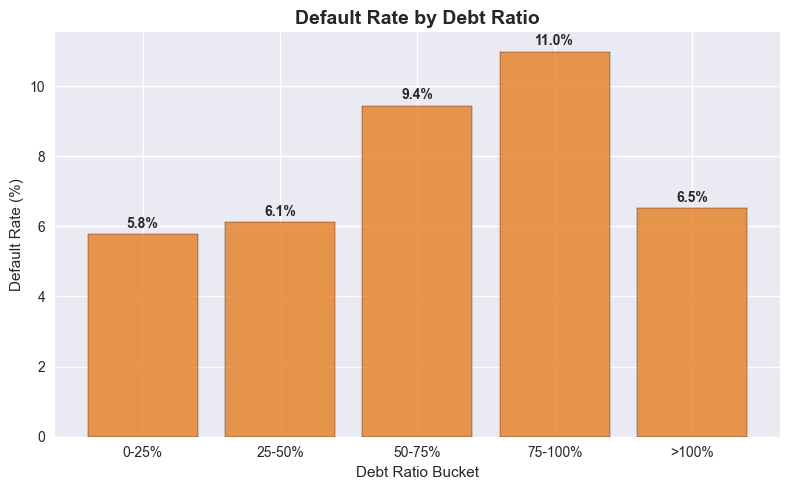

Plot saved.


In [14]:
df['debt_bucket'] = pd.cut(df['DebtRatio'].clip(0, 2), 
                            bins=[0, 0.25, 0.5, 0.75, 1.0, 2.0],
                            labels=['0-25%', '25-50%', '50-75%', '75-100%', '>100%'])

default_by_debt = df.groupby('debt_bucket', observed=True)['SeriousDlqin2yrs'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(default_by_debt.index, default_by_debt.values,
              color='#e67e22', edgecolor='black', alpha=0.8)

ax.set_title('Default Rate by Debt Ratio', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt Ratio Bucket')
ax.set_ylabel('Default Rate (%)')

for bar, val in zip(bars, default_by_debt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/05_default_rate_by_debt.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop('debt_bucket', axis=1, inplace=True)
print("Plot saved.")

In [15]:
# Summary statistics
summary = df.describe().round(2)
summary.to_csv('../outputs/reports/eda_summary_stats.csv')

# Missing values summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0]
missing.to_csv('../outputs/reports/missing_values_summary.csv')

print("=== EDA COMPLETE ===")
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Default rate: {df['SeriousDlqin2yrs'].mean()*100:.1f}%")
print(f"Missing values in MonthlyIncome: {df['MonthlyIncome'].isnull().sum():,}")
print(f"Missing values in NumberOfDependents: {df['NumberOfDependents'].isnull().sum():,}")
print("\n5 plots saved to outputs/plots/")
print("2 reports saved to outputs/reports/")
print("\nReady for Notebook 2: Preprocessing")

=== EDA COMPLETE ===
Dataset: 150,000 rows, 11 columns
Default rate: 6.7%
Missing values in MonthlyIncome: 29,731
Missing values in NumberOfDependents: 3,924

5 plots saved to outputs/plots/
2 reports saved to outputs/reports/

Ready for Notebook 2: Preprocessing
